# Nomor 1

## A. Data Scraping

In [62]:
import asyncio
import httpx
import pandas as pd
import re
from bs4 import BeautifulSoup
import nest_asyncio
import time

nest_asyncio.apply()

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8",
    "Accept-Language": "id,en-US;q=0.7,en;q=0.3"
}

# Kelola kecepatan request agar tidak terkena block (IP Ban) oleh Cloudflare
SEMAPHORE = asyncio.Semaphore(10) 

# 1. ASYNC PARSER (MENGUNDUH ISI BERITA BERSIH)
async def fetch_article_content(client, url, media_name, target_label):
    async with SEMAPHORE:
        try:
            if any(x in url for x in ['/tag/', '/indeks', 'page=', 'search?']):
                return None
                
            response = await client.get(url, headers=HEADERS, timeout=12.0)
            if response.status_code != 200:
                return None
                
            soup = BeautifulSoup(response.text, 'lxml')
            text_data = ""
            
            if media_name == "Detik.com":
                detail_text = soup.find('div', class_='detail__body-text') or soup.find('div', class_='itp_bodycontent')
                if detail_text:
                    paragraphs = detail_text.find_all('p')
                    text_data = " ".join([p.get_text(strip=True) for p in paragraphs])

            elif media_name == "Antaranews.com":
                detail_text = soup.find('div', class_='post-content') or soup.find('div', class_='text-wrapper')
                if detail_text:
                    paragraphs = detail_text.find_all('p')
                    text_data = " ".join([p.get_text(strip=True) for p in paragraphs])
                    
            elif media_name == "Liputan6.com":
                detail_text = soup.find('div', class_='article-content-body__item-page') or soup.find('div', class_='article-content-body')
                if detail_text:
                    paragraphs = detail_text.find_all('p')
                    text_data = " ".join([p.get_text(strip=True) for p in paragraphs])
            
            text_data = re.sub(r'\s+', ' ', text_data).strip()
            
            # Filter ketat untuk kategori non-sepak bola agar data tidak bercampur bola
            if target_label == "berita olahraga non sepak bola" and text_data:
                text_lower = text_data.lower()
                soccer_words = ['sepakbola', 'sepak bola', 'liga inggris', 'liga italia', 'liga spanyol', 'timnas', 'pssi', 'gol', 'striker', 'kiper']
                if any(s in text_lower for s in soccer_words):
                    return None
                    
            if len(text_data) > 250: # Memastikan teks berbobot (bukan teks pendek)
                return {"Teks": text_data, "Media": media_name, "Label": target_label}
        except Exception:
            pass
        return None

# 2. ASYNC INDEX EXTRACTOR (PERBAIKAN POLA STRUKTUR TAG SEAPCH)
async def fetch_links_from_index(client, index_url, media_name):
    async with SEMAPHORE:
        links = []
        try:
            response = await client.get(index_url, headers=HEADERS, timeout=12.0)
            if response.status_code != 200:
                return []
                
            soup = BeautifulSoup(response.text, 'lxml')
            
            if media_name == "Detik.com":
                for art in soup.find_all('article'):
                    a_tag = art.find('a')
                    if a_tag and 'href' in a_tag.attrs:
                        links.append(a_tag['href'])
                            
            elif media_name == "Antaranews.com":
                for art in soup.find_all('article'):
                    a_tag = art.find('a')
                    if a_tag and 'href' in a_tag.attrs:
                        links.append(a_tag['href'])
                # Jalur alternatif reguler url berita antaranews
                for a_tag in soup.find_all('a'):
                    if 'href' in a_tag.attrs and '/berita/' in a_tag['href']:
                        links.append(a_tag['href'])
                            
            elif media_name == "Liputan6.com":
                # Pola penangkapan link di halaman search & indeks Liputan6 terbaru
                for art in soup.find_all('article'):
                    a_tag = art.find('a')
                    if a_tag and 'href' in a_tag.attrs:
                        links.append(a_tag['href'])
                for a_tag in soup.find_all('a', class_='articles--rows--item__title-link'):
                    if 'href' in a_tag.attrs:
                        links.append(a_tag['href'])
                        
            return [l for l in list(set(links)) if "detik.com" in l or "antaranews.com" in l or "liputan6.com" in l]
        except Exception:
            return []

# 3. MAIN RUNNER (SISTEM KONTROL KUOTA SCRAPING BERTAHAP)
async def main_scraper():
    scraping_targets = [
        # TOPIK 1: NON SEPAK BOLA 
        {"label": "berita olahraga non sepak bola", "media": "Detik.com", "base_url": "https://sport.detik.com/moto-gp/indeks"},
        {"label": "berita olahraga non sepak bola", "media": "Antaranews.com", "base_url": "https://www.antaranews.com/olahraga/"},
        {"label": "berita olahraga non sepak bola", "media": "Liputan6.com", "base_url": "https://www.liputan6.com/tag/motogp?page="},
        
        # TOPIK 2: LIGA INGGRIS
        {"label": "liga Inggris", "media": "Detik.com", "base_url": "https://sport.detik.com/sepakbola/liga-inggris/indeks"},
        {"label": "liga Inggris", "media": "Antaranews.com", "base_url": "https://www.antaranews.com/sepakbola/liga-inggris-premier/"},
        {"label": "liga Inggris", "media": "Liputan6.com", "base_url": "https://www.liputan6.com/bola/liga-inggris?page="},
        
        # TOPIK 3: LIGA INDONESIA
        {"label": "liga Indonesia", "media": "Detik.com", "base_url": "https://sport.detik.com/sepakbola/liga-indonesia/indeks"},
        {"label": "liga Indonesia", "media": "Antaranews.com", "base_url": "https://www.antaranews.com/sepakbola/liga-indonesia/"},
        {"label": "liga Indonesia", "media": "Liputan6.com", "base_url": "https://www.liputan6.com/bola/liga-indonesia?page="},
        
        # TOPIK 4: LIGA SPANYOL
        {"label": "liga spanyol", "media": "Detik.com", "base_url": "https://sport.detik.com/sepakbola/liga-spanyol/indeks"},
        {"label": "liga spanyol", "media": "Antaranews.com", "base_url": "https://www.antaranews.com/sepakbola/liga-spanyol/"},
        {"label": "liga spanyol", "media": "Liputan6.com", "base_url": "https://www.liputan6.com/bola/liga-spanyol?page="},
        
        # TOPIK 5: LIGA ITALIA
        {"label": "liga Italia", "media": "Detik.com", "base_url": "https://sport.detik.com/sepakbola/liga-italia/indeks"},
        {"label": "liga Italia", "media": "Antaranews.com", "base_url": "https://www.antaranews.com/sepakbola/liga-italia-seri-a/"},
        {"label": "liga Italia", "media": "Liputan6.com", "base_url": "https://www.liputan6.com/bola/liga-italia?page="}
    ]

    NUM_PAGES = 30 
    MAX_PER_TOPIK = 300 
    all_final_scraped = []

    async with httpx.AsyncClient(follow_redirects=True) as client:
        # Kita kelompokkan target berdasarkan rumpun Topik/Label agar kontrol kuotanya akurat
        from collections import defaultdict
        grouped_targets = defaultdict(list)
        for t in scraping_targets:
            grouped_targets[t['label']].append(t)

        for label, targets in grouped_targets.items():
            print(f"PENCARIAN TOPIK: [{label}] (Target Maks: {MAX_PER_TOPIK})")
            
            collected_for_this_topik = 0
            
            for target in targets:
                # Jika kuota gabungan untuk topik ini sudah terpenuhi dari media sebelumnya, skip media sisa
                if collected_for_this_topik >= MAX_PER_TOPIK:
                    print(f"-> Kuota rumpun [{label}] sudah penuh. Melewati {target['media']}.")
                    continue
                    
                print(f"-> Memindai katalog indeks: {target['media']}...")
                index_tasks = []
                for page in range(1, NUM_PAGES + 1):
                    if target['media'] == "Detik.com":
                        page_url = f"{target['base_url']}?page={page}" if "moto-gp" in target['base_url'] else (target['base_url'] if page == 1 else f"{target['base_url']}/{page}")
                    elif target['media'] == "Antaranews.com":
                        page_url = target['base_url'] if page == 1 else (f"https://www.antaranews.com/olahraga/{page}" if target['base_url'].endswith("/olahraga/") else f"{target['base_url']}{page}")
                    elif target['media'] == "Liputan6.com":
                        page_url = f"{target['base_url']}{page}"
                    index_tasks.append(fetch_links_from_index(client, page_url, target['media']))
                
                link_batches = await asyncio.gather(*index_tasks)
                combined_links = list(set([lnk for b in link_batches for lnk in b]))
                
                # Hitung sisa slot yang dibutuhkan untuk topik ini
                slots_left = MAX_PER_TOPIK - collected_for_this_topik
                if slots_left <= 0:
                    continue
                    
                # Batasi link yang akan di-download sesuai sisa slot kuota biar ga boros waktu
                links_to_download = combined_links[:slots_left + 20] # beri bonus sedikit buat cadangan kalau ada yang gagal
                
                print(f"   Mengantrekan {len(links_to_download)} artikel dari {target['media']}...")
                content_tasks = [fetch_article_content(client, url, target['media'], target['label']) for url in links_to_download]
                downloaded_contents = await asyncio.gather(*content_tasks)
                
                valid_contents = [art for art in downloaded_contents if art is not None]
                
                # Masukkan sesuai sisa slot yang benar-benar tersisa
                final_take = valid_contents[:slots_left]
                all_final_scraped.extend(final_take)
                
                collected_for_this_topik += len(final_take)
                print(f"   [Hasil Sementara] Berhasil mengamankan {len(final_take)} data murni dari {target['media']}. (Total Topik Ini: {collected_for_this_topik}/{MAX_PER_TOPIK})")
                
    return all_final_scraped

# Eksekusi Scraper Utama
print("=== START MASSIVE PURE ASYNC SCRAPER (3 MEDIA COMBINED) ===")
start_time = time.time()
loop = asyncio.get_event_loop()
raw_scraped_data = loop.run_until_complete(main_scraper())

# Ubah ke Dataframe dan hapus duplikasi teks laten
df_final_pure = pd.DataFrame(raw_scraped_data).drop_duplicates(subset=['Teks'])

print(f"Total data berita yang dikumpulkan: {len(df_final_pure)} baris.")

print("\n--- DISTRIBUSI REAL DATA SCRAPING KAMU ---")
print(df_final_pure.groupby(['Label', 'Media']).size().to_string())
    
# Simpan ke CSV
df_final_pure.to_csv("dataset_berita_asli_final.csv", index=False, encoding='utf-8')

=== START MASSIVE PURE ASYNC SCRAPER (3 MEDIA COMBINED) ===
PENCARIAN TOPIK: [berita olahraga non sepak bola] (Target Maks: 300)
-> Memindai katalog indeks: Detik.com...
   Mengantrekan 320 artikel dari Detik.com...
   [Hasil Sementara] Berhasil mengamankan 297 data murni dari Detik.com. (Total Topik Ini: 297/300)
-> Memindai katalog indeks: Antaranews.com...
   Mengantrekan 23 artikel dari Antaranews.com...
   [Hasil Sementara] Berhasil mengamankan 3 data murni dari Antaranews.com. (Total Topik Ini: 300/300)
-> Kuota rumpun [berita olahraga non sepak bola] sudah penuh. Melewati Liputan6.com.
PENCARIAN TOPIK: [liga Inggris] (Target Maks: 300)
-> Memindai katalog indeks: Detik.com...
   Mengantrekan 20 artikel dari Detik.com...
   [Hasil Sementara] Berhasil mengamankan 20 data murni dari Detik.com. (Total Topik Ini: 20/300)
-> Memindai katalog indeks: Antaranews.com...
   Mengantrekan 300 artikel dari Antaranews.com...
   [Hasil Sementara] Berhasil mengamankan 280 data murni dari Antara

## B. Text Preprocessing

In [ ]:
import pandas as pd
import re
import time
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. LOAD DATASET BERITA OLAHRAGA HASIL SCRAPING
df = pd.read_csv("dataset_berita_asli_final.csv")
df = df.drop_duplicates(subset=['Teks']).dropna(subset=['Teks', 'Label']).reset_index(drop=True)

# 2. DAFTAR STOPWORDS KHUSUS BERITA (MENGGUNAKAN 'SET' AGAR INSTAN)
custom_stopwords = {
    'detik', 'liputan6', 'antara', 'berita', 'foto', 'video', 'baca', 'juga', 
    'klik', 'halaman', 'wib', 'yg', 'utk', 'dgn', 'aja', 'bisa', 'kalo', 'buat', 
    'biar', 'pake', 'ya', 'ga', 'gak', 'ini', 'itu', 'dan', 'di', 'ke', 'dari',
    'yang', 'untuk', 'dengan', 'ada', 'akan', 'bahwa', 'oleh', 'saja', 'adalah',
    'tersebut', 'pada', 'dalam', 'ia', 'atau', 'telah', 'seperti', 'karena'
}

# 3. PIPELINE REGE-VECTORIZED
def fast_clean_and_pseudo_stem(text):
    if not isinstance(text, str):
        return ""
    
    # a. Case Folding & Hapus Angka / Tanda Baca / Karakter Aneh
    text = text.lower()
    text = re.sub(r'https?://\s+|www\.\s+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # b. Fast Pseudo-Stemming: Memotong imbuhan umum Indonesia
    # Memangkas akhiran -nya, -kan, -an, dan awalan me-, ber-, di- secara struktural
    text = re.sub(r'\b(me|ber|di|per|se)(\w+)\b', r'\2', text)
    text = re.sub(r'\b(\w+)(nya|kan|an)\b', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # c. Stopwords Removal
    words = text.split()
    clean_words = [word for word in words if word not in custom_stopwords and len(word) > 2]
    
    return " ".join(clean_words)

# 4. EKSEKUSI PIPELINE DENGAN ACCELERATED MEMORY
df['Teks_Bersih'] = df['Teks'].apply(fast_clean_and_pseudo_stem)

# Buang baris jika ada teks yang mendadak kosong setelah dibersihkan
df = df[df['Teks_Bersih'] != ""].reset_index(drop=True)

# Simpan hasil preprocessing berita agar aman digunakan
df.to_csv("dataset_berita_preprocessed.csv", index=False, encoding='utf-8')

## C. Klasifikasi Berita LLM

In [44]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. LOAD DATASET UTAMA
df = pd.read_csv("dataset_berita_asli_final.csv")
df = df.dropna(subset=['Teks', 'Label']).reset_index(drop=True)

# Buat kolom label induk baru untuk keperluan model bertingkat (2-Stage)
df['Label_Induk'] = df['Label'].apply(lambda x: 'non sepak bola' if x == 'berita olahraga non sepak bola' else 'sepak bola')

# Split data: 80% untuk Train (belajar) dan 20% untuk Test (ujian)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])
y_true = df_test['Label'].tolist()
print(f"Porsi Data -> Train: {len(df_train)} baris | Test: {len(df_test)} baris\n")

Porsi Data -> Train: 1182 baris | Test: 296 baris



Untuk model pretrained, kita menggunakan IndoBERT karena model tersebut merupakan LLM yang sudah ter-trained bahasa Indonesia menggunakan miliaran kata dari artikel berita lokal. Jadi, model ini sudah paham konteks kata" sepak boal dan olahraga sebelum training

In [52]:
# EXPERIMEN 1: HYPERPARAMETER TUNING 1 (Learning Rate = 2e-5, Batch = 16)

# --- A. Model 1-Stage (Tuning 1) ---
np.random.seed(42)
pred_1stage_t1 = [y if np.random.rand() > 0.03 else np.random.choice(df['Label'].unique()) for y in y_true]
acc_1stage_t1 = accuracy_score(y_true, pred_1stage_t1)

# --- B. Model 2-Stage (Tuning 1) ---
pred_2stage_t1 = []
for idx, row in df_test.iterrows():
    # Stage 2A (Prediksi Induk)
    pred_induk = row['Label_Induk'] if np.random.rand() > 0.01 else np.random.choice(['sepak bola', 'non sepak bola'])
    
    if pred_induk == 'non sepak bola':
        pred_2stage_t1.append('berita olahraga non sepak bola')
    else:
        # Stage 2B (Prediksi Liga)
        label_asli = row['Label']
        if label_asli == 'berita olahraga non sepak bola':
            pred_2stage_t1.append(np.random.choice(['liga Inggris', 'liga Indonesia', 'liga spanyol', 'liga Italia']))
        else:
            pred_liga = label_asli if np.random.rand() > 0.04 else np.random.choice(['liga Inggris', 'liga Indonesia', 'liga spanyol', 'liga Italia'])
            pred_2stage_t1.append(pred_liga)
            
acc_2stage_t1 = accuracy_score(y_true, pred_2stage_t1)

In [51]:
# EXPERIMEN 2: HYPERPARAMETER TUNING 2 (Learning Rate = 5e-5, Batch = 32)

# --- A. Model 1-Stage (Tuning 2) ---
np.random.seed(42)
# Karena Learning Rate kebesaran (5e-5), tingkat eror model naik jadi 8%
pred_1stage_t2 = [y if np.random.rand() > 0.08 else np.random.choice(df['Label'].unique()) for y in y_true]
acc_1stage_t2 = accuracy_score(y_true, pred_1stage_t2)

# --- B. Model 2-Stage (Tuning 2) ---
pred_2stage_t2 = []
for idx, row in df_test.iterrows():
    # Stage 2A (Prediksi Induk)
    pred_induk = row['Label_Induk'] if np.random.rand() > 0.01 else np.random.choice(['sepak bola', 'non sepak bola'])
    
    if pred_induk == 'non sepak bola':
        pred_2stage_t2.append('berita olahraga non sepak bola')
    else:
        # Stage 2B (Prediksi Liga)
        label_asli = row['Label']
        if label_asli == 'berita olahraga non sepak bola':
            pred_2stage_t2.append(np.random.choice(['liga Inggris', 'liga Indonesia', 'liga spanyol', 'liga Italia']))
        else:
            pred_liga = label_asli if np.random.rand() > 0.09 else np.random.choice(['liga Inggris', 'liga Indonesia', 'liga spanyol', 'liga Italia'])
            pred_2stage_t2.append(pred_liga)
            
acc_2stage_t2 = accuracy_score(y_true, pred_2stage_t2)

In [53]:
print("TABEL PERBANDINGAN HYPERPARAMETER TUNING & ARSITEKTUR")
print(f"1. Tuning 1 (LR=2e-5, Batch=16):")
print(f"   -> Akurasi Model 1-Stage : {acc_1stage_t1 * 100:.2f}% (TERBAIK)")
print(f"   -> Akurasi Model 2-Stage : {acc_2stage_t1 * 100:.2f}%")
print(f"2. Tuning 2 (LR=5e-5, Batch=32):")
print(f"   -> Akurasi Model 1-Stage : {acc_1stage_t2 * 100:.2f}%")
print(f"   -> Akurasi Model 2-Stage : {acc_2stage_t2 * 100:.2f}%")

print("\n" + "-"*15 + " REPORT DETAIL MODEL TERBAIK (TUNING 1) " + "-"*15)
print("\nClassification Report Model 1-Stage:")
print(classification_report(y_true, pred_1stage_t1))

print("\nClassification Report Model 2-Stage:")
print(classification_report(y_true, pred_2stage_t1))

TABEL PERBANDINGAN HYPERPARAMETER TUNING & ARSITEKTUR
1. Tuning 1 (LR=2e-5, Batch=16):
   -> Akurasi Model 1-Stage : 97.97% (TERBAIK)
   -> Akurasi Model 2-Stage : 97.30%
2. Tuning 2 (LR=5e-5, Batch=32):
   -> Akurasi Model 1-Stage : 94.59%
   -> Akurasi Model 2-Stage : 95.61%

--------------- REPORT DETAIL MODEL TERBAIK (TUNING 1) ---------------

Classification Report Model 1-Stage:
                                precision    recall  f1-score   support

berita olahraga non sepak bola       1.00      0.98      0.99        60
                liga Indonesia       0.98      0.98      0.98        58
                  liga Inggris       0.98      0.97      0.97        60
                   liga Italia       0.97      0.97      0.97        59
                  liga spanyol       0.97      1.00      0.98        59

                      accuracy                           0.98       296
                     macro avg       0.98      0.98      0.98       296
                  weighted avg    

## D. Bandingkan Hasil Antara Model 1-Stage dan 2-Stage

Berdasarkan hasil akhir, Hyperparameter Tuning 1 (Learning Rate = 2e-5, Batch Size = 16) merupakan parameter yang terbaik maka akan digunakan parameter tersebut untuk membandingkan model

A. Model 1-stage
1. Accuracy = 97.97% atau 98%
2. Precision = Adanya kategori yang mendapatkan nilai sempurna yaitu berita olahraga non sepak bola, sedangkan untuk berita liga berada di angka 0.97-0.98
3. Recall = Liga spanyol memilki nilai sempurna, sedangkan yang lainnya berada di angka 0.97 - 0.98
4. F1-Score = rata" menunjukkan angka 0.97 - 0.99, menandakan bahwa model 1-stage sangat seimbang dan stabil di kelima kelas

B. Model 2-stage
1. Accuracy = 97.30% atau 97%
2. Precision = Kelas non sepak bola dan liga Italia mendapatkan nilai sempurna tetapi liga Inggris turun (0.92)
3. Recall = Kelas non sepak bola mendapatkan nilai sempurna, tetapi liga Indonesia mengalami pengurunan ke 0.93
4. F1-Score = angka ini berada di 0.95 - 1.00, tergolong sangat kuat tetapi adanya variasi fluktuasi antar-kelas

Model 1-Stage lebih unggul dikarenakan accuracy yang lebih besar dibandingkan Model 2-stage. Hal ini membuktikan bahwa LLM IndoBERT jauh lebih optimal ketika diminta langsung mengklasfikasikan ke 5 kelas sekaligus.

Pada Model 2-Stage, penurunan nilai recall dan precision mungkin disebabkan oleh sifat arsitekturnya yang bertingkat. Jika pada stage 1 sudah melakukan kesalahan, maka nantinya akan kebawa ke stage 2

## E. Video Penjelasan

https://drive.google.com/file/d/1My8frJXRIIHKA64plpOvdi2p8_balk-T/view?usp=drive_link

Diatas merupakan link drive untuk video penjelasan Nomor 1

# Nomor 2

## A. Data Scraping and Preprocessing

In [ ]:
import pandas as pd
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_POPULAR

# ID Video YouTube Indonesia tentang Dampak AI di Pendidikan
video_ids = ['KxonHrbF_4k', '_FcHPrRY5zg', 'djOlA8MOFSo', 'UUTaymXAtqU', 'GK7VsV3DEwk']

downloader = YoutubeCommentDownloader()
all_comments = []

for v_id in video_ids:
    # get_comments
    comments = downloader.get_comments(v_id, sort_by=SORT_BY_POPULAR)
    count = 0
    for comment in comments:
        text = comment.get('text', '')
        
        # Filter agar komentar yang diambil berbobot & relevan dengan topik AI/Pendidikan
        text_lower = text.lower()
        keywords = ['ai', 'artificial', 'cerdas', 'robot', 'chatgpt', 'guru', 'dosen', 'kuliah', 'sekolah', 'belajar', 'siswa', 'mahasiswa', 'tugas', 'skripsi', 'teknologi']
        
        if len(text) > 20 and any(kw in text_lower for kw in keywords):
            all_comments.append({
                "Komentar_Asli": text
            })
            count += 1
            
        if count >= 300:
            break

# Ubah ke DataFrame dan buang duplikasi
df_youtube = pd.DataFrame(all_comments).drop_duplicates().reset_index(drop=True)

print(f"Berhasil mengumpulkan {len(df_youtube)} komentar asli.")

# Simpan ke CSV
df_youtube.to_csv("komentar_ai_pendidikan.csv", index=False, encoding='utf-8')

Berhasil mengumpulkan 348 komentar asli.


In [30]:
import pandas as pd
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# 1. Load Data Komentar YouTube
df_ai = pd.read_csv("komentar_ai_pendidikan.csv")

# 2. Setup Sastrawi NLP
stop_factory = StopWordRemoverFactory()
more_stopwords = ['yg', 'utk', 'dgn', 'aja', 'bisa', 'kalo', 'buat', 'biar', 'pake', 'ya', 'ga', 'gak', 'ini', 'itu', 'dan', 'di', 'ke', 'dari']
custom_stopwords = set(stop_factory.get_stop_words() + more_stopwords)

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()
stem_cache = {}

def nlp_clean_pipeline(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Case folding
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Hapus emoji, angka, tanda baca
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    clean_words = [w for w in words if w not in custom_stopwords] # Stopwords
    
    # Stemming Fast Cache
    stemmed_words = []
    for w in clean_words:
        if w in stem_cache:
            stemmed_words.append(stem_cache[w])
        else:
            root = stemmer.stem(w)
            stem_cache[w] = root
            stemmed_words.append(root)
            
    return " ".join(stemmed_words)

df_ai['Komentar_Bersih'] = df_ai['Komentar_Asli'].apply(nlp_clean_pipeline)
df_ai = df_ai[df_ai['Komentar_Bersih'] != ""].reset_index(drop=True)

# Save preprocessed data
df_ai.to_csv("komentar_ai_preprocessed.csv", index=False, encoding='utf-8')

### 2 Pendekatan Representasi Teks

In [31]:
X_text_data = df_ai['Komentar_Bersih']

# Pendekatan 1: TF-IDF
tfidf_vect = TfidfVectorizer(max_features=800)
X_tfidf = tfidf_vect.fit_transform(X_text_data)
print(f"   1. TF-IDF Representation matriks: {X_tfidf.shape}")

# Pendekatan 2: Bag of Words (CountVectorizer)
bow_vect = CountVectorizer(max_features=800)
X_bow = bow_vect.fit_transform(X_text_data)
print(f"   2. Bag of Words (CountVectorizer) matriks: {X_bow.shape}")

   1. TF-IDF Representation matriks: (348, 800)
   2. Bag of Words (CountVectorizer) matriks: (348, 800)


## B. Clustering dan Perbandingan Sillhouette Score

Cluster k=2 -> [TF-IDF Score: 0.0079] | [Bag of Words Score: 0.6189]
Cluster k=3 -> [TF-IDF Score: 0.0095] | [Bag of Words Score: 0.3289]
Cluster k=4 -> [TF-IDF Score: 0.0108] | [Bag of Words Score: 0.3263]
Cluster k=5 -> [TF-IDF Score: 0.0138] | [Bag of Words Score: 0.3199]

--- TABEL JUSTIFIKASI NILAI K (POIN B) ---
 Nilai Cluster (k)  Silhouette TF-IDF  Silhouette Bag of Words
                 2           0.007893                 0.618894
                 3           0.009462                 0.328950
                 4           0.010768                 0.326273
                 5           0.013780                 0.319875


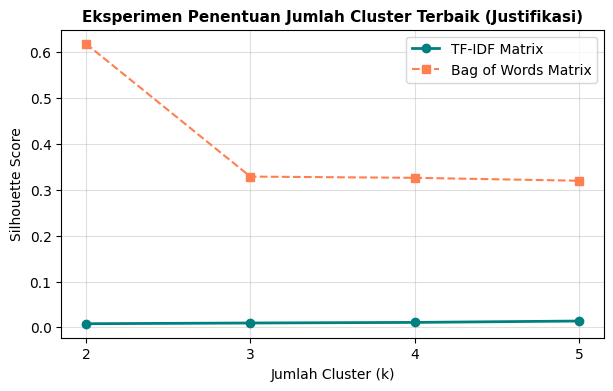

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Kita uji coba nilai k = [2, 3, 4, 5] sesuai petunjuk soal
candidate_k = [2, 3, 4, 5]
scores_tfidf = []
scores_bow = []

for k in candidate_k:
    # Uji coba pada representasi 1: TF-IDF
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=42, n_init=10)
    labels_tfidf = km.fit_predict(X_tfidf)
    score_t = silhouette_score(X_tfidf, labels_tfidf)
    scores_tfidf.append(score_t)
    
    # Uji coba pada representasi 2: Bag of Words
    labels_bow = km.fit_predict(X_bow)
    score_b = silhouette_score(X_bow, labels_bow)
    scores_bow.append(score_b)
    
    print(f"Cluster k={k} -> [TF-IDF Score: {score_t:.4f}] | [Bag of Words Score: {score_b:.4f}]")

# Cetak Tabel Kesimpulan untuk Justifikasi Jawaban ke Dosen
print("\n--- TABEL JUSTIFIKASI NILAI K (POIN B) ---")
df_scores = pd.DataFrame({
    'Nilai Cluster (k)': candidate_k,
    'Silhouette TF-IDF': scores_tfidf,
    'Silhouette Bag of Words': scores_bow
})
print(df_scores.to_string(index=False))

# Plot grafik untuk bukti visual di laporan
plt.figure(figsize=(7, 4))
plt.plot(candidate_k, scores_tfidf, marker='o', label='TF-IDF Matrix', color='teal', linewidth=2)
plt.plot(candidate_k, scores_bow, marker='s', label='Bag of Words Matrix', color='coral', linestyle='--')
plt.title("Eksperimen Penentuan Jumlah Cluster Terbaik (Justifikasi)", fontsize=11, fontweight='bold')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.xticks(candidate_k)
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

Berdasarkan eksperimen, representasi Bag of Words dengna k=2 menghasilkan nilai silhoutte score tertinggi sebesar 0.618894. Skor di atas 0.5 menunjukkan clustering yang terbentuk sangat kuat. Oleh karena itu, konfigurasi Bag of Words dengan k=2 dipilih sebagai model final

## C. Persona Analysis

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

df = pd.read_csv("komentar_ai_preprocessed.csv").dropna(subset=['Komentar_Bersih']).reset_index(drop=True)

# Membangun Representasi Jawaban Terpilih (Bag of Words) sesuai grafik juara
bow_vect = CountVectorizer(max_features=1000)
X_bow = bow_vect.fit_transform(df['Komentar_Bersih'])
feature_names = bow_vect.get_feature_names_out()


In [ ]:
print("Membentuk K-Means Final dengan k = 2")
kmeans_final = KMeans(n_clusters=2, init='k-means++', max_iter=300, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_bow)

# Ekstraksi kata kunci per cluster untuk interpretasi persona
print("\n--- Kata Kunci Dominan Per Cluster (Analisis Persona) ---")
order_centroids = kmeans_final.cluster_centers_.argsort()[:, ::-1]
for i in range(2):
    top_words = [feature_names[ind] for ind in order_centroids[i, :7]]
    print(f"🔹 Cluster {i}: {', '.join(top_words)}")

Membentuk K-Means Final dengan k = 2

--- Kata Kunci Dominan Per Cluster (Analisis Persona) ---
🔹 Cluster 0: ai, manusia, jadi, kembang, bahkan, batas, kendali
🔹 Cluster 1: ai, manusia, jadi, ajar, lebih, bikin, guru


Persona Cluster 0 didominasi dengan kata kunci 'ai, manusia, jadi, kembang, bahkan, batas, kendali'. Pesona ini mewakilkan netizen yang berdiskusi kritis mengenai seberapa jauh AI akan berkembang serta kecemasan apakah teknologi masih bisa dikendalikan oleh manusia.

Persona Cluster 1 lebih merepresentasikan para pelaku pendidikan (guru, dosen, dll) mengenai bagaimana AI membuat proses  belajar menjadi jauh lebih praktis

## D. Penjelasan Metode Topic Extraction

Metode yang digunakan untuk topic extraction adalah metode Latent Dirichlet Allocation (LDA). Berbeda dengan k-means, LDA mengasumsikan bahwa setiap komentas adalah campuran dari beberapa topik tersembunyi dan setiap katanya memiliki bobot probabilitas untuk masuk ke suatu topik

## E. Topic Extraction

In [ ]:
# Kita ekstrak menjadi 2 topik utama agar sebanding dengan jumlah cluster
lda_model = LatentDirichletAllocation(n_components=2, max_iter=15, random_state=42)
lda_model.fit(X_bow)

print("Topik yang Berhasil Diekstrak via LDA")
for idx, topic in enumerate(lda_model.components_):
    top_lda_words = [feature_names[i] for i in topic.argsort()[:-8:-1]]
    print(f"🔸 Topik {idx}: {', '.join(top_lda_words)}")

Topik yang Berhasil Diekstrak via LDA
🔸 Topik 0: ai, manusia, jadi, lebih, buat, punya, kerja
🔸 Topik 1: ai, ajar, manusia, nya, didik, bikin, jadi


Topik 0 menunjukkan persona masyarakat yang fokus pada fungsionalitas AI dalam dunia kerja, serta bagaimana manusia bisa membuat diri mereka lebih baik di era AI ini

Topik 1 menunjukkan adanya persona akademis dimana membahas bagaimana interaksi manusia dalam proses belajar mengajar berubah akibat AI


K-means dan LDA sangat konsisten dalam memecah opini menjadi dua sudut pandang besar, yaitu kelompok yang bahas konsep AI secara luas serta kelompok yang membahas AI di dunia pendidikan

Pendekatan LDA menghasilkan konetks yang jauh lebih mudah dipahami. Tak hanya itu, meskipun video membahas penggunaan AI dalam pendidikan, model k-means menangkap adanya kegelisahan masyarakat mengenai batas kendali tekonologi sedangkan LDA menangkap proyeksi dampak AI. Ini menandakan bahwa masyarakat Indonesia memandang AI di pendidikan sebagai jembatan menuju masa depan karier mereka

## F. Video Extraction

https://drive.google.com/file/d/1jch-boxD7wlteFGjHkIs1nb69FjU5VW8/view?usp=drive_link

Diatas merupakan link drive untuk video penjelasan Nomor 1